Feature matrix shape: (9022, 48)
Labels shape: (9022,)
Gesture classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


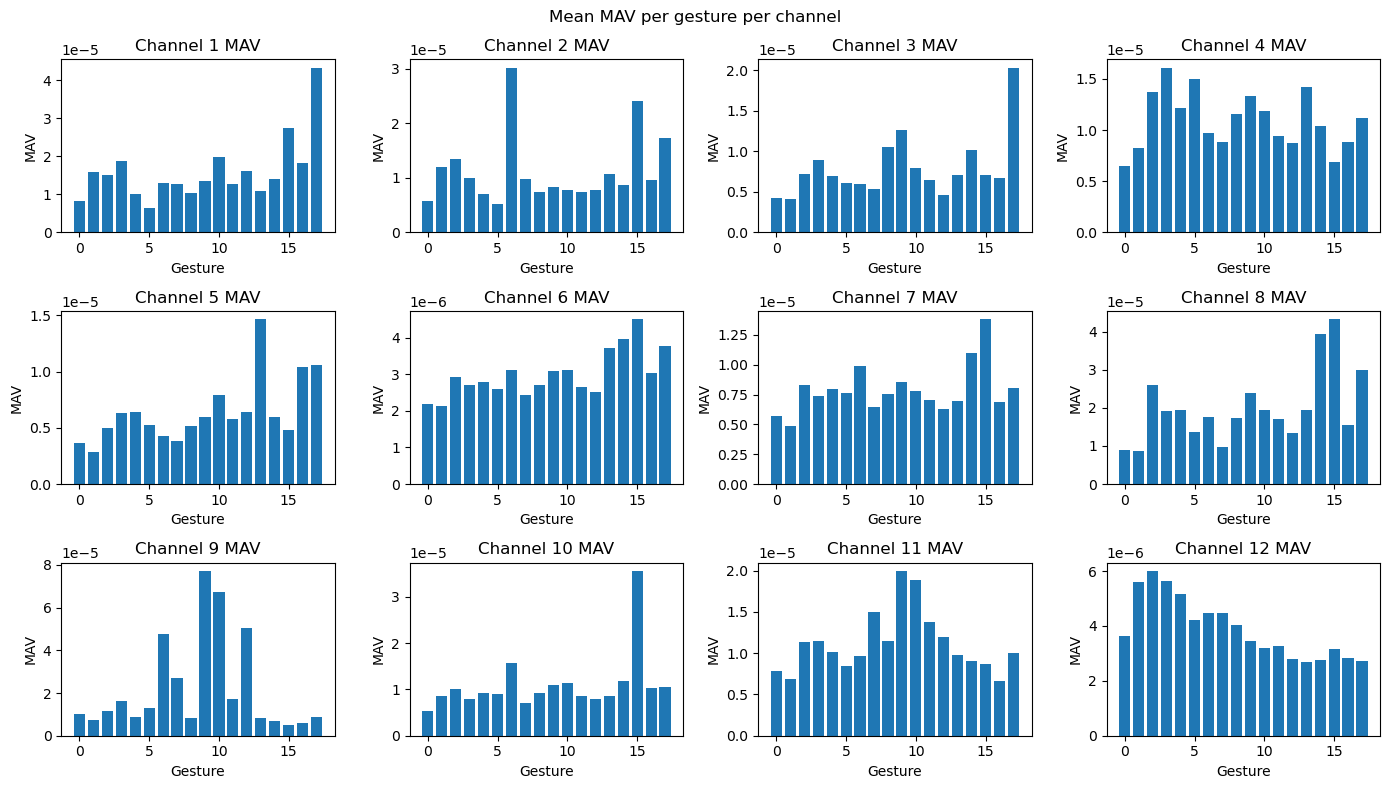

In [ ]:
import sys
sys.path.append('../src')

import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from preprocessing import filterAllChannels
from features import extractAllWindows
from config import FS, N_CHANNELS

# Load data
data = sio.loadmat('../data/S17_E1_A1.mat')
emg = data['emg']
labels = data['restimulus']

# Preprocess and extract features
emg_filtered = filterAllChannels(emg)
X, y = extractAllWindows(emg_filtered, labels)

print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Gesture classes: {np.unique(y)}")

fig, axes = plt.subplots(3, 4, figsize=(14, 8))
axes = axes.flatten()

for ch in range(N_CHANNELS):
    mavFeatureIdx = ch * 4
    
    gestureMeans = []
    for gesture in range(18):
        mask = y == gesture
        if mask.sum() > 0:
            gestureMeans.append(X[mask, mavFeatureIdx].mean())
        else:
            gestureMeans.append(0)
    
    axes[ch].bar(range(18), gestureMeans)
    axes[ch].set_title(f'Channel {ch+1} MAV')
    axes[ch].set_xlabel('Gesture')
    axes[ch].set_ylabel('MAV')

plt.suptitle('Mean MAV per gesture per channel', fontsize=12)
plt.tight_layout()
plt.show()